In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
print("All imports OK")

All imports OK


In [2]:
url = "https://huggingface.co/datasets/HUBioDataLab/SELFormerMM/resolve/main/finetuning_datasets/classification/bbbp/bbbp.csv"
df = pd.read_csv(url)
df = df[['smiles', 'p_np']].dropna().reset_index(drop=True)
print(f"Dataset: {len(df)} compounds")
print(df['p_np'].value_counts())

Dataset: 2039 compounds
p_np
1    1560
0     479
Name: count, dtype: int64


In [5]:
# GNN simulatoin with atom-level features

from rdkit.Chem import Descriptors
from rdkit import DataStructs

def get_atom_features(atom):
    return np.array([
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        int(atom.IsInRing()),
    ], dtype=float)

def message_passing(mol, steps=2):
    # simulate GNN message passing manually
    n_atoms = mol.GetNumAtoms()
    if n_atoms == 0:
        return None

    # node features
    node_feats = np.array([get_atom_features(mol.GetAtomWithIdx(i))
                          for i in range(n_atoms)], dtype=float)

    # adjacency matrix
    adj = np.zeros((n_atoms, n_atoms))
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        adj[i, j] = 1
        adj[j, i] = 1

    # message passing: average neighbor features
    h = node_feats.copy()
    for _ in range(steps):
        deg = adj.sum(axis=1, keepdims=True).clip(min=1)
        h = (adj @ h) / deg + h

    # graph-level readout: mean + max pooling
    graph_mean = h.mean(axis=0)
    graph_max = h.max(axis=0)
    return np.concatenate([graph_mean, graph_max])

def compute_atom_importance(mol):
    # leave one atom out importance for explainability
    n_atoms = mol.GetNumAtoms()
    base = message_passing(mol)
    if base is None:
        return np.zeros(n_atoms)

    importances = np.zeros(n_atoms)
    for i in range(n_atoms):
        mask = [j for j in range(n_atoms) if j !=i]
        node_feats = np.array([get_atom_features(mol.GetAtomWithIdx(j))
                              for j in mask], dtype=float)
        if len(node_feats) == 0:
            continue
        adj = np.zeros((len(mask), len(mask)))
        idx_map = {v: k for k, v in enumerate(mask)}
        for bond in mol.GetBonds():
            bi, bj = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            if bi in idx_map and bj in idx_map:
                adj[idx_map[bi], idx_map[bj]] = 1
                adj[idx_map[bj], idx_map[bi]] = 1
        h = node_feats.copy()
        for _ in range(2):
            deg = adj.sum(axis=1, keepdims=True).clip(min=1)
            h = (adj @ h) / deg + h
        modified = np.concatenate([h.mean(axis=0), h.max(axis=0)])
        importances[i] = np.linalg.norm(base - modified)
    return importances

print("Functions defined ok...")
                

Functions defined ok...


In [6]:
# featurize all molecules

features = []
valid_idx = []

for i, smi in enumerate(df['smiles']):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    feat = message_passing(mol)
    if feat is not None:
        features.append(feat)
        valid_idx.append(i)

X = np.array(features)
y = df['p_np'].iloc[valid_idx].values
print(f"Feature matrix: {X.shape}")
print(f"Labels: {y.shape}")

[16:29:24] WARNING: not removing hydrogen atom without neighbors
[16:29:24] WARNING: not removing hydrogen atom without neighbors
[16:29:24] WARNING: not removing hydrogen atom without neighbors
[16:29:24] WARNING: not removing hydrogen atom without neighbors
[16:29:24] WARNING: not removing hydrogen atom without neighbors
[16:29:24] WARNING: not removing hydrogen atom without neighbors
[16:29:24] WARNING: not removing hydrogen atom without neighbors
[16:29:24] WARNING: not removing hydrogen atom without neighbors
[16:29:24] WARNING: not removing hydrogen atom without neighbors
[16:29:24] WARNING: not removing hydrogen atom without neighbors
[16:29:24] WARNING: not removing hydrogen atom without neighbors
[16:29:24] WARNING: not removing hydrogen atom without neighbors
[16:29:24] WARNING: not removing hydrogen atom without neighbors
[16:29:24] WARNING: not removing hydrogen atom without neighbors
[16:29:24] WARNING: not removing hydrogen atom without neighbors
[16:29:24] WARNING: not r

Feature matrix: (2039, 10)
Labels: (2039,)


[16:29:25] WARNING: not removing hydrogen atom without neighbors
[16:29:25] WARNING: not removing hydrogen atom without neighbors
[16:29:25] WARNING: not removing hydrogen atom without neighbors
[16:29:25] WARNING: not removing hydrogen atom without neighbors
[16:29:25] WARNING: not removing hydrogen atom without neighbors
[16:29:25] WARNING: not removing hydrogen atom without neighbors
[16:29:25] WARNING: not removing hydrogen atom without neighbors


In [8]:
# Model training and Eval

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
model = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight='balanced'
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.3f}")
print(classification_report(y_test, y_pred))

ROC-AUC: 0.855
              precision    recall  f1-score   support

           0       0.79      0.48      0.60        96
           1       0.86      0.96      0.91       312

    accuracy                           0.85       408
   macro avg       0.83      0.72      0.75       408
weighted avg       0.84      0.85      0.83       408



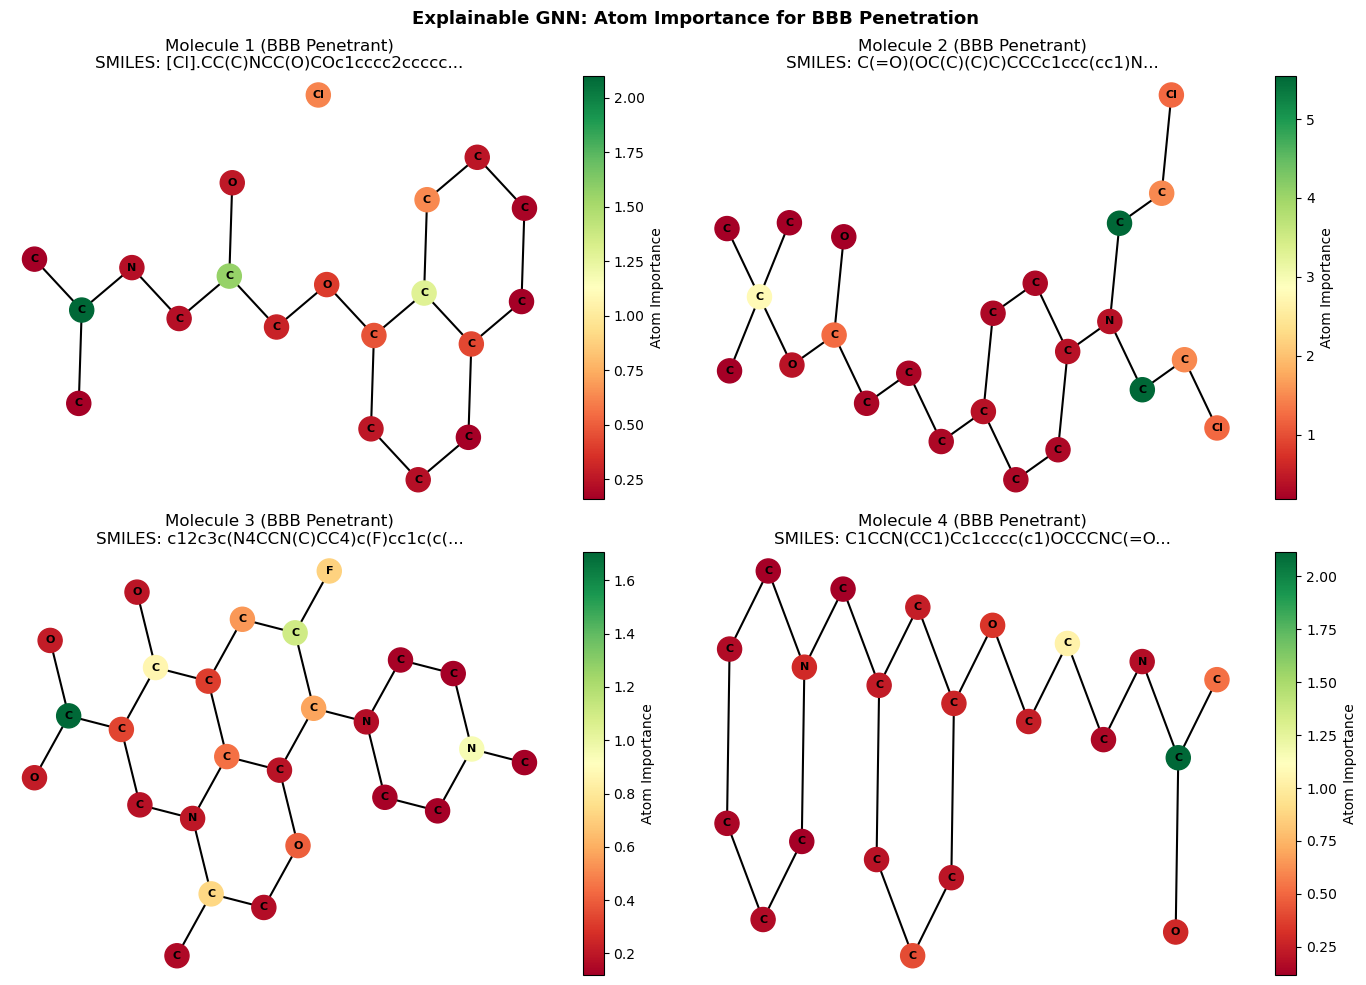

Saved!


In [9]:
# Explainability

# 4 sample molecules from the test set
sample_smiles = df['smiles'].iloc[valid_idx].reset_index(drop=True)
sample_labels = df['p_np'].iloc[valid_idx].reset_index(drop=True)

examples = sample_smiles[sample_labels == 1].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, smi in enumerate(examples):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    
    importances = compute_atom_importance(mol)
    norm = Normalize(vmin=importances.min(), vmax=importances.max())
    cmap = plt.cm.RdYlGn

    # scatter plot of atoms
    from rdkit.Chem import AllChem
    AllChem.Compute2DCoords(mol)
    conf = mol.GetConformer()
    
    xs = [conf.GetAtomPosition(i).x for i in range(mol.GetNumAtoms())]
    ys = [conf.GetAtomPosition(i).y for i in range(mol.GetNumAtoms())]
    colors = [cmap(norm(importances[i])) for i in range(mol.GetNumAtoms())]
    symbols = [mol.GetAtomWithIdx(i).GetSymbol() for i in range(mol.GetNumAtoms())]

    # plotting bonds
    for bond in mol.GetBonds():
        bi, bj = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        axes[idx].plot([xs[bi], xs[bj]], [ys[bi], ys[bj]], 'k-', lw=1.5, zorder=1)
    
    # plotting atoms
    sc = axes[idx].scatter(xs, ys, c=importances, cmap='RdYlGn',
                           s=300, zorder=2, norm=norm)
    
    for i, (x, y_coord, sym) in enumerate(zip(xs, ys, symbols)):
        axes[idx].annotate(sym, (x, y_coord), ha='center', va='center',
                          fontsize=8, fontweight='bold', zorder=3)
    
    plt.colorbar(sc, ax=axes[idx], label='Atom Importance')
    axes[idx].set_title(f'Molecule {idx+1} (BBB Penetrant)\nSMILES: {smi[:30]}...')
    axes[idx].axis('off')

plt.suptitle('Explainable GNN: Atom Importance for BBB Penetration', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('explainability.png', dpi=150)
plt.show()
print("Saved!")

In [10]:
# Summary

print("=" * 55)
print("   PROJECT D - EXPLAINABLE GNN SUMMARY")
print("=" * 55)
print(f"Dataset:        BBBP ({len(df)} compounds)")
print(f"Architecture:   2-step Message Passing (numpy)")
print(f"Node features:  atomic num, degree, charge, aromaticity, ring")
print(f"Readout:        mean + max pooling")
print(f"Explainability: Leave-one-atom-out importance")
print(f"Model:          Random Forest on graph embeddings")
print(f"ROC-AUC:        {auc:.3f}")
print("=" * 55)

   PROJECT D - EXPLAINABLE GNN SUMMARY
Dataset:        BBBP (2039 compounds)
Architecture:   2-step Message Passing (numpy)
Node features:  atomic num, degree, charge, aromaticity, ring
Readout:        mean + max pooling
Explainability: Leave-one-atom-out importance
Model:          Random Forest on graph embeddings
ROC-AUC:        0.855
